
Loaded files:
24SRA-int.csv
24SRB-int.csv
24SRG-int.csv
24SRK-int.csv
24SRL-int.csv

MEAN + STD FORECAST RESULTS: 24SRA-int
 forecast_index  forecast_day forecast_date  H_obs  H_forecast  H_error  H_upper  H_lower  BM_obs  BM_forecast  BM_error  BM_upper  BM_lower  BH_obs  BH_forecast  BH_error  BH_upper  BH_lower  L_obs  L_forecast  L_error  L_upper  L_lower
             12          84.0    2024-09-30    4.0      2.4167  -1.5833   2.9977   1.8357  0.0886       0.0085   -0.0801    0.0285   -0.0116  5.9114       8.4082    2.4968    9.3492    7.4672    5.0      4.5000  -0.5000   5.9061   3.0939
             13         113.0    2024-10-29    7.0      2.5833  -4.4167   3.2934   1.8732  0.1639       0.0158   -0.1481    0.0455   -0.0138  9.8361       8.0675   -1.7686    9.1057    7.0293    2.0      4.2500   2.2500   5.2064   3.2936
             14         135.0    2024-11-20    8.0      3.0000  -5.0000   4.3885   1.6115  0.1078       0.0295   -0.0783    0.0795   -0.0205  5.8922       8.0816

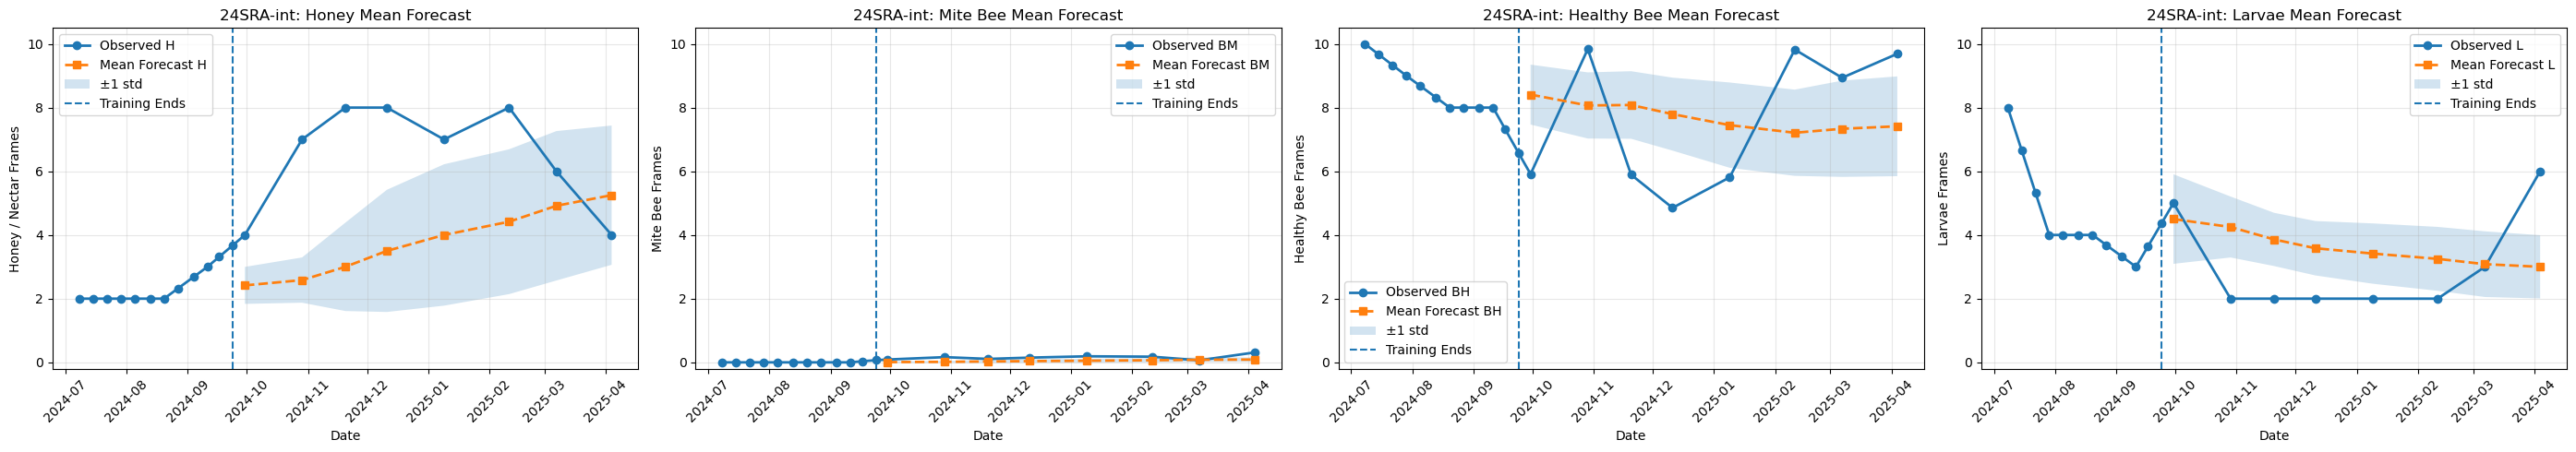

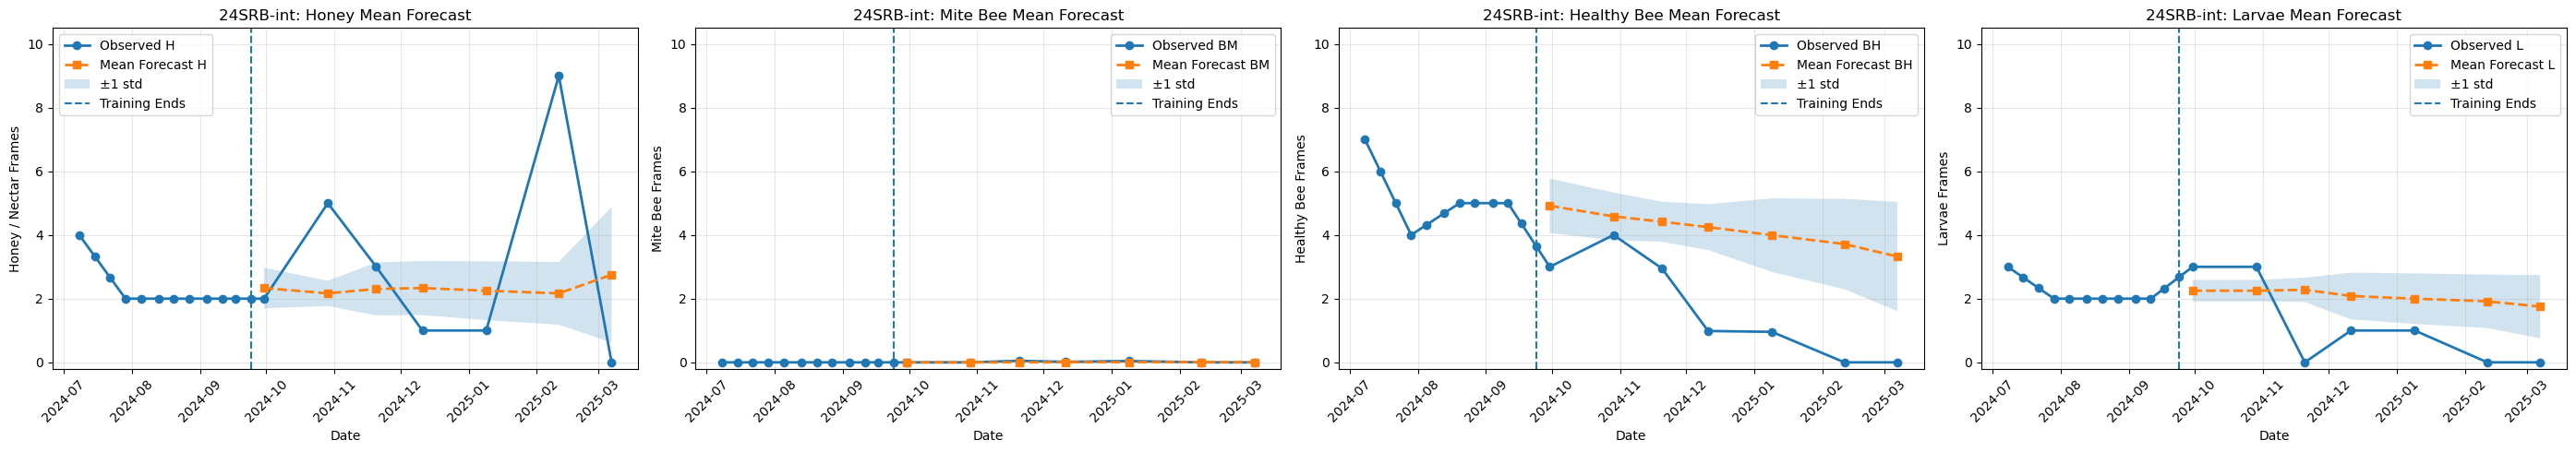

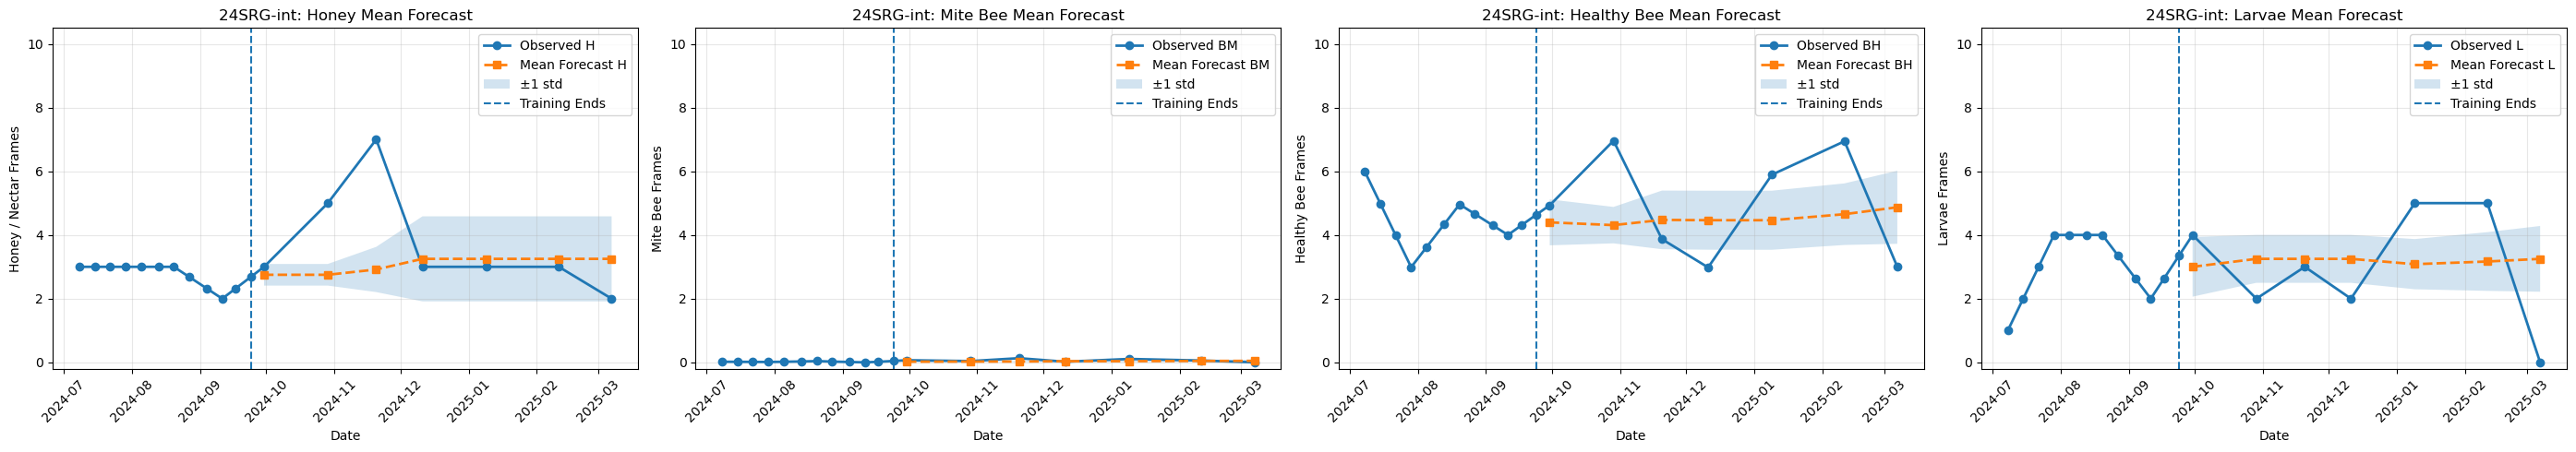

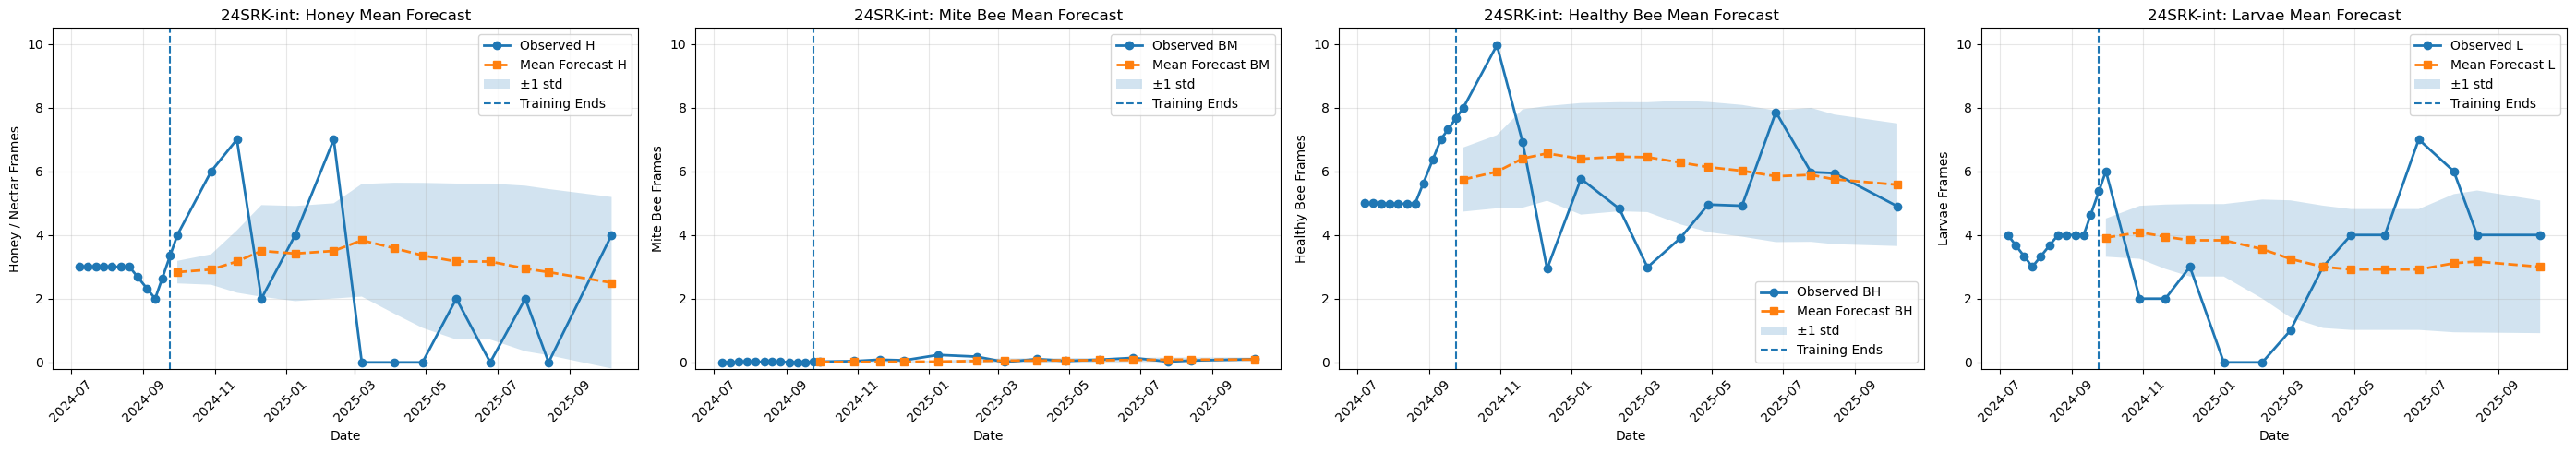

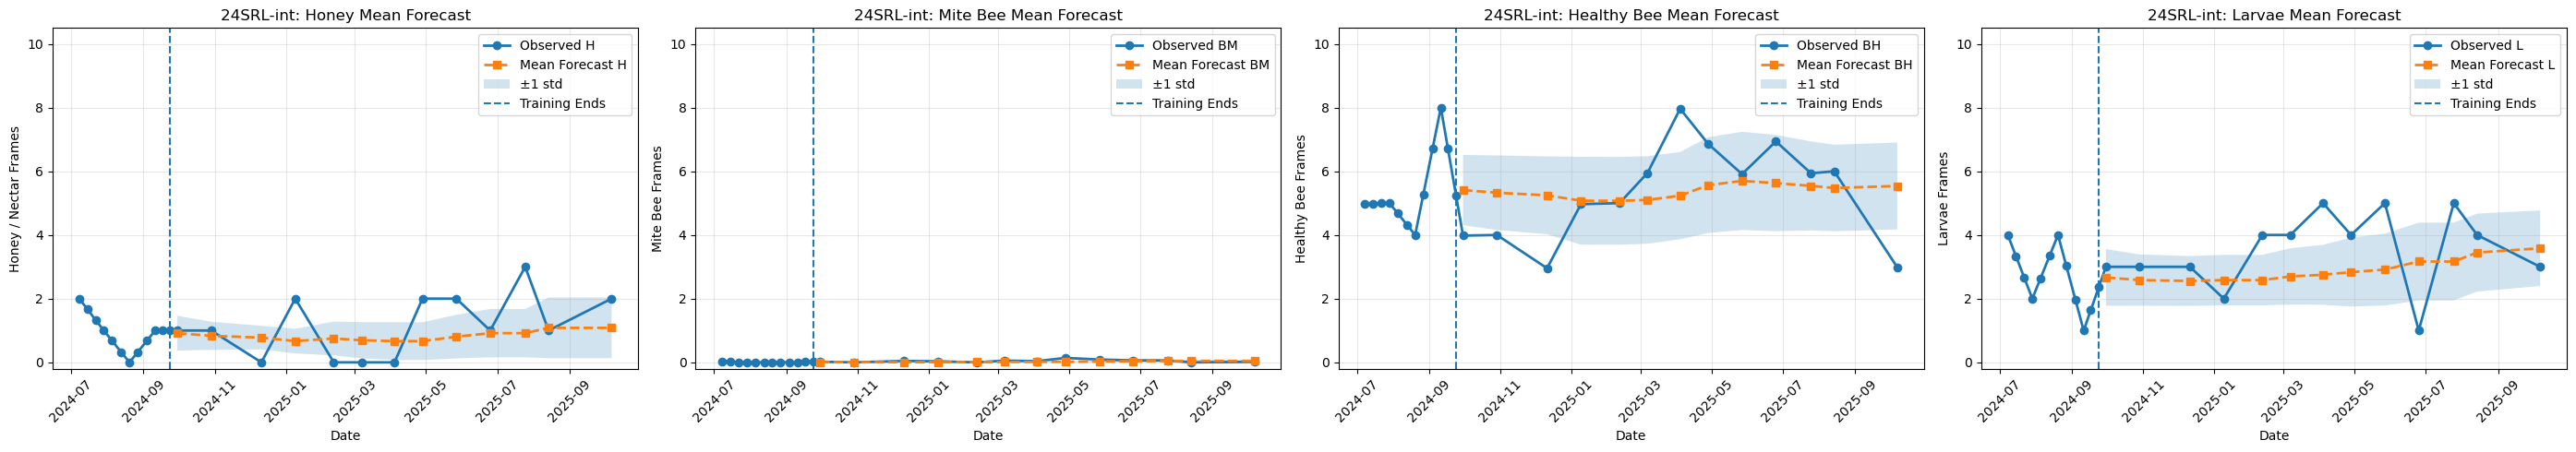

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import pandas as pd
import glob
import os

# ============================================================
# SETTINGS
# ============================================================

DATA_FOLDER = r"C:\Bee Temp Data\24SR-train-int"

# ============================================================
# LOAD DATA
# ============================================================

csv_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "*.csv")))

print("\nLoaded files:")
for f in csv_files:
    print(os.path.basename(f))

all_hives = []

for file in csv_files:
    data = pd.read_csv(file)
    data["Date"] = pd.to_datetime(data["Date"])

    H_obs = np.array(data["Nectar"], dtype=float)
    L_obs = np.array(data["Frames Brood"], dtype=float)
    BM_obs = np.array(data["Frames Mites"], dtype=float)
    BH_obs = np.array(data["Frame Healthy Bees"], dtype=float)

    hive = {
        "name": os.path.basename(file).replace(".csv", ""),
        "data": data,
        "t": np.array(data["Day"], dtype=float),
        "dates": np.array(data["Date"]),
        "obs": {
            "H": H_obs,
            "L": L_obs,
            "BM": BM_obs,
            "BH": BH_obs,
            "B": BM_obs + BH_obs,
        },
    }

    all_hives.append(hive)

# ============================================================
# SETTINGS
# ============================================================

TRAIN_POINTS = 12
WINDOW_SIZE = 12

# ============================================================
# MEAN + STD FORECAST
#
# Forecast = mean of sliding training window
# Uncertainty = ±1 std of sliding training window
#
# Forecasting starts from same point as before.
# ============================================================

forecast_records = {}

for hive in all_hives:

    name = hive["name"]

    t_all = hive["t"]
    dates = hive["dates"]

    obsH = hive["obs"]["H"]
    obsBM = hive["obs"]["BM"]
    obsBH = hive["obs"]["BH"]
    obsL = hive["obs"]["L"]

    records = []

    # --------------------------------------------------------
    # Forecast starts after TRAIN_POINTS
    # --------------------------------------------------------

    for forecast_idx in range(TRAIN_POINTS, len(t_all)):

        # Sliding window
        window_start = forecast_idx - WINDOW_SIZE
        window_end = forecast_idx

        if window_start < 0:
            continue

        # ====================================================
        # TRAINING WINDOW
        # ====================================================

        H_window = obsH[window_start:window_end]
        BM_window = obsBM[window_start:window_end]
        BH_window = obsBH[window_start:window_end]
        L_window = obsL[window_start:window_end]

        # ====================================================
        # FORECAST = MEAN OF WINDOW
        # ====================================================

        H_forecast = np.mean(H_window)
        BM_forecast = np.mean(BM_window)
        BH_forecast = np.mean(BH_window)
        L_forecast = np.mean(L_window)

        # ====================================================
        # UNCERTAINTY = STD OF WINDOW
        # ====================================================

        H_std = np.std(H_window)
        BM_std = np.std(BM_window)
        BH_std = np.std(BH_window)
        L_std = np.std(L_window)

        records.append({

            "forecast_index": forecast_idx,
            "forecast_day": t_all[forecast_idx],
            "forecast_date": dates[forecast_idx],

            # ------------------------------------------------
            # Honey
            # ------------------------------------------------

            "H_obs": obsH[forecast_idx],
            "H_forecast": H_forecast,
            "H_error": H_forecast - obsH[forecast_idx],
            "H_upper": H_forecast + H_std,
            "H_lower": H_forecast - H_std,

            # ------------------------------------------------
            # Mite bees
            # ------------------------------------------------

            "BM_obs": obsBM[forecast_idx],
            "BM_forecast": BM_forecast,
            "BM_error": BM_forecast - obsBM[forecast_idx],
            "BM_upper": BM_forecast + BM_std,
            "BM_lower": BM_forecast - BM_std,

            # ------------------------------------------------
            # Healthy bees
            # ------------------------------------------------

            "BH_obs": obsBH[forecast_idx],
            "BH_forecast": BH_forecast,
            "BH_error": BH_forecast - obsBH[forecast_idx],
            "BH_upper": BH_forecast + BH_std,
            "BH_lower": BH_forecast - BH_std,

            # ------------------------------------------------
            # Larvae
            # ------------------------------------------------

            "L_obs": obsL[forecast_idx],
            "L_forecast": L_forecast,
            "L_error": L_forecast - obsL[forecast_idx],
            "L_upper": L_forecast + L_std,
            "L_lower": L_forecast - L_std,
        })

    forecast_records[name] = pd.DataFrame(records)

# ============================================================
# PRINT FORECAST RESULTS
# ============================================================

for hive in all_hives:

    name = hive["name"]
    df_forecast = forecast_records[name]

    print("\n" + "=" * 80)
    print(f"MEAN + STD FORECAST RESULTS: {name}")
    print("=" * 80)

    if len(df_forecast) == 0:
        print("No forecast records.")
        continue

    print(df_forecast.round(4).to_string(index=False))

    H_rmse = np.sqrt(np.mean(df_forecast["H_error"] ** 2))
    BM_rmse = np.sqrt(np.mean(df_forecast["BM_error"] ** 2))
    BH_rmse = np.sqrt(np.mean(df_forecast["BH_error"] ** 2))
    L_rmse = np.sqrt(np.mean(df_forecast["L_error"] ** 2))

    print("\nMean Forecast RMSE:")
    print(f"H RMSE  = {H_rmse:.4f}")
    print(f"BM RMSE = {BM_rmse:.4f}")
    print(f"BH RMSE = {BH_rmse:.4f}")
    print(f"L RMSE  = {L_rmse:.4f}")

# ============================================================
# PLOT FORECASTS
# ============================================================

for hive in all_hives:

    name = hive["name"]

    dates = hive["dates"]

    obsH = hive["obs"]["H"]
    obsBM = hive["obs"]["BM"]
    obsBH = hive["obs"]["BH"]
    obsL = hive["obs"]["L"]

    df_forecast = forecast_records[name]

    if len(df_forecast) == 0:
        continue

    fig, axs = plt.subplots(1, 4, figsize=(28, 5))

    # ========================================================
    # HONEY
    # ========================================================

    axs[0].plot(dates, obsH, "o-", label="Observed H", linewidth=2)

    axs[0].plot(
        df_forecast["forecast_date"],
        df_forecast["H_forecast"],
        "s--",
        label="Mean Forecast H",
        linewidth=2,
    )

    axs[0].fill_between(
        df_forecast["forecast_date"],
        df_forecast["H_lower"],
        df_forecast["H_upper"],
        alpha=0.2,
        label="±1 std",
    )

    axs[0].axvline(
        x=dates[TRAIN_POINTS - 1],
        linestyle="--",
        linewidth=1.5,
        label="Training Ends",
    )

    axs[0].set_title(f"{name}: Honey Mean Forecast")
    axs[0].set_xlabel("Date")
    axs[0].set_ylabel("Honey / Nectar Frames")
    axs[0].set_ylim(-0.2, 10.5)
    axs[0].grid(alpha=0.3)
    axs[0].legend()
    axs[0].tick_params(axis="x", rotation=45)

    # ========================================================
    # MITE BEES
    # ========================================================

    axs[1].plot(dates, obsBM, "o-", label="Observed BM", linewidth=2)

    axs[1].plot(
        df_forecast["forecast_date"],
        df_forecast["BM_forecast"],
        "s--",
        label="Mean Forecast BM",
        linewidth=2,
    )

    axs[1].fill_between(
        df_forecast["forecast_date"],
        df_forecast["BM_lower"],
        df_forecast["BM_upper"],
        alpha=0.2,
        label="±1 std",
    )

    axs[1].axvline(
        x=dates[TRAIN_POINTS - 1],
        linestyle="--",
        linewidth=1.5,
        label="Training Ends",
    )

    axs[1].set_title(f"{name}: Mite Bee Mean Forecast")
    axs[1].set_xlabel("Date")
    axs[1].set_ylabel("Mite Bee Frames")
    axs[1].set_ylim(-0.2, 10.5)
    axs[1].grid(alpha=0.3)
    axs[1].legend()
    axs[1].tick_params(axis="x", rotation=45)

    # ========================================================
    # HEALTHY BEES
    # ========================================================

    axs[2].plot(dates, obsBH, "o-", label="Observed BH", linewidth=2)

    axs[2].plot(
        df_forecast["forecast_date"],
        df_forecast["BH_forecast"],
        "s--",
        label="Mean Forecast BH",
        linewidth=2,
    )

    axs[2].fill_between(
        df_forecast["forecast_date"],
        df_forecast["BH_lower"],
        df_forecast["BH_upper"],
        alpha=0.2,
        label="±1 std",
    )

    axs[2].axvline(
        x=dates[TRAIN_POINTS - 1],
        linestyle="--",
        linewidth=1.5,
        label="Training Ends",
    )

    axs[2].set_title(f"{name}: Healthy Bee Mean Forecast")
    axs[2].set_xlabel("Date")
    axs[2].set_ylabel("Healthy Bee Frames")
    axs[2].set_ylim(-0.2, 10.5)
    axs[2].grid(alpha=0.3)
    axs[2].legend()
    axs[2].tick_params(axis="x", rotation=45)

    # ========================================================
    # LARVAE
    # ========================================================

    axs[3].plot(dates, obsL, "o-", label="Observed L", linewidth=2)

    axs[3].plot(
        df_forecast["forecast_date"],
        df_forecast["L_forecast"],
        "s--",
        label="Mean Forecast L",
        linewidth=2,
    )

    axs[3].fill_between(
        df_forecast["forecast_date"],
        df_forecast["L_lower"],
        df_forecast["L_upper"],
        alpha=0.2,
        label="±1 std",
    )

    axs[3].axvline(
        x=dates[TRAIN_POINTS - 1],
        linestyle="--",
        linewidth=1.5,
        label="Training Ends",
    )

    axs[3].set_title(f"{name}: Larvae Mean Forecast")
    axs[3].set_xlabel("Date")
    axs[3].set_ylabel("Larvae Frames")
    axs[3].set_ylim(-0.2, 10.5)
    axs[3].grid(alpha=0.3)
    axs[3].legend()
    axs[3].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()